In [17]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [3]:
# 1. Load the latent vectors from your trained model
experiment_dir = "/home/jakaria/INR/Deep3DComp/examples/torus/sixteen_variable_z" 
checkpoint = "latest" 

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f"Loaded latent vectors with shape: {X.shape}")

Loaded latent vectors with shape: (369, 16)


In [4]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_dir, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            params["bump_size"] = float(label[3].item())
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
            params["bump_size"] = 0.0        
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/labels.pt
All labels: {'torus_bump_0000': array([0.        , 1.        , 0.46153846, 0.08361204]), 'torus_bump_0001': array([1.        , 1.        , 0.8361204 , 0.64548495]), 'torus_bump_0002': array([0.        , 1.        , 0.96655518, 0.0735786 ]), 'torus_bump_0003': array([1.        , 1.        , 0.98327759, 0.26421405]), 'torus_bump_0004': array([0.        , 1.        , 0.66889632, 0.48494983]), 'torus_bump_0005': array([1.        , 1.        , 0.92976589, 0.54849498]), 'torus_bump_0006': array([0.        , 1.        , 0.85284281, 0.52508361]), 'torus_bump_0007': array([1.        , 1.        , 0.84949833, 0.73578595]), 'torus_bump_0008': array([0.        , 1.        , 0.04682274, 0.17391304]), 'torus_bump_0009': array([1.        , 1.        , 0.56187291, 0.7993311 ]), 'torus_bump_0010': array([0.        , 1.        , 0.62207358, 0.89297659]), 'toru

In [5]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])
bump_sizes = np.array([p.get("bump_size", 0.0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales, bump_sizes))
factor_names = ["bump", "scale", "bump_size"]

In [6]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [7]:

# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(300, 320, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [2]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_bump)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.3129
Correlation between distance from origin and scale: -0.0628


[0.9246336691793327, 0.07212083847187409]
n_neighbors: 300, n_components: 2, best component correlation: 0.9246
[-0.05529929753395482, 0.9249144437740663]
n_neighbors: 310, n_components: 2, best component correlation: 0.9249

Best parameter set:
n_neighbors: 310, n_components: 2, best component: 1 best correlation: 0.9249


In [8]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [2, 3, 4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_bump)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 2, best component correlation: 0.8979
n_components: 3, best component correlation: -0.8870
n_components: 4, best component correlation: 0.8181

Best NMF parameter set:
n_components: 2, best correlation: 0.8979


In [9]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=2, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and scale: -0.1161


In [10]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and scale: -0.0722


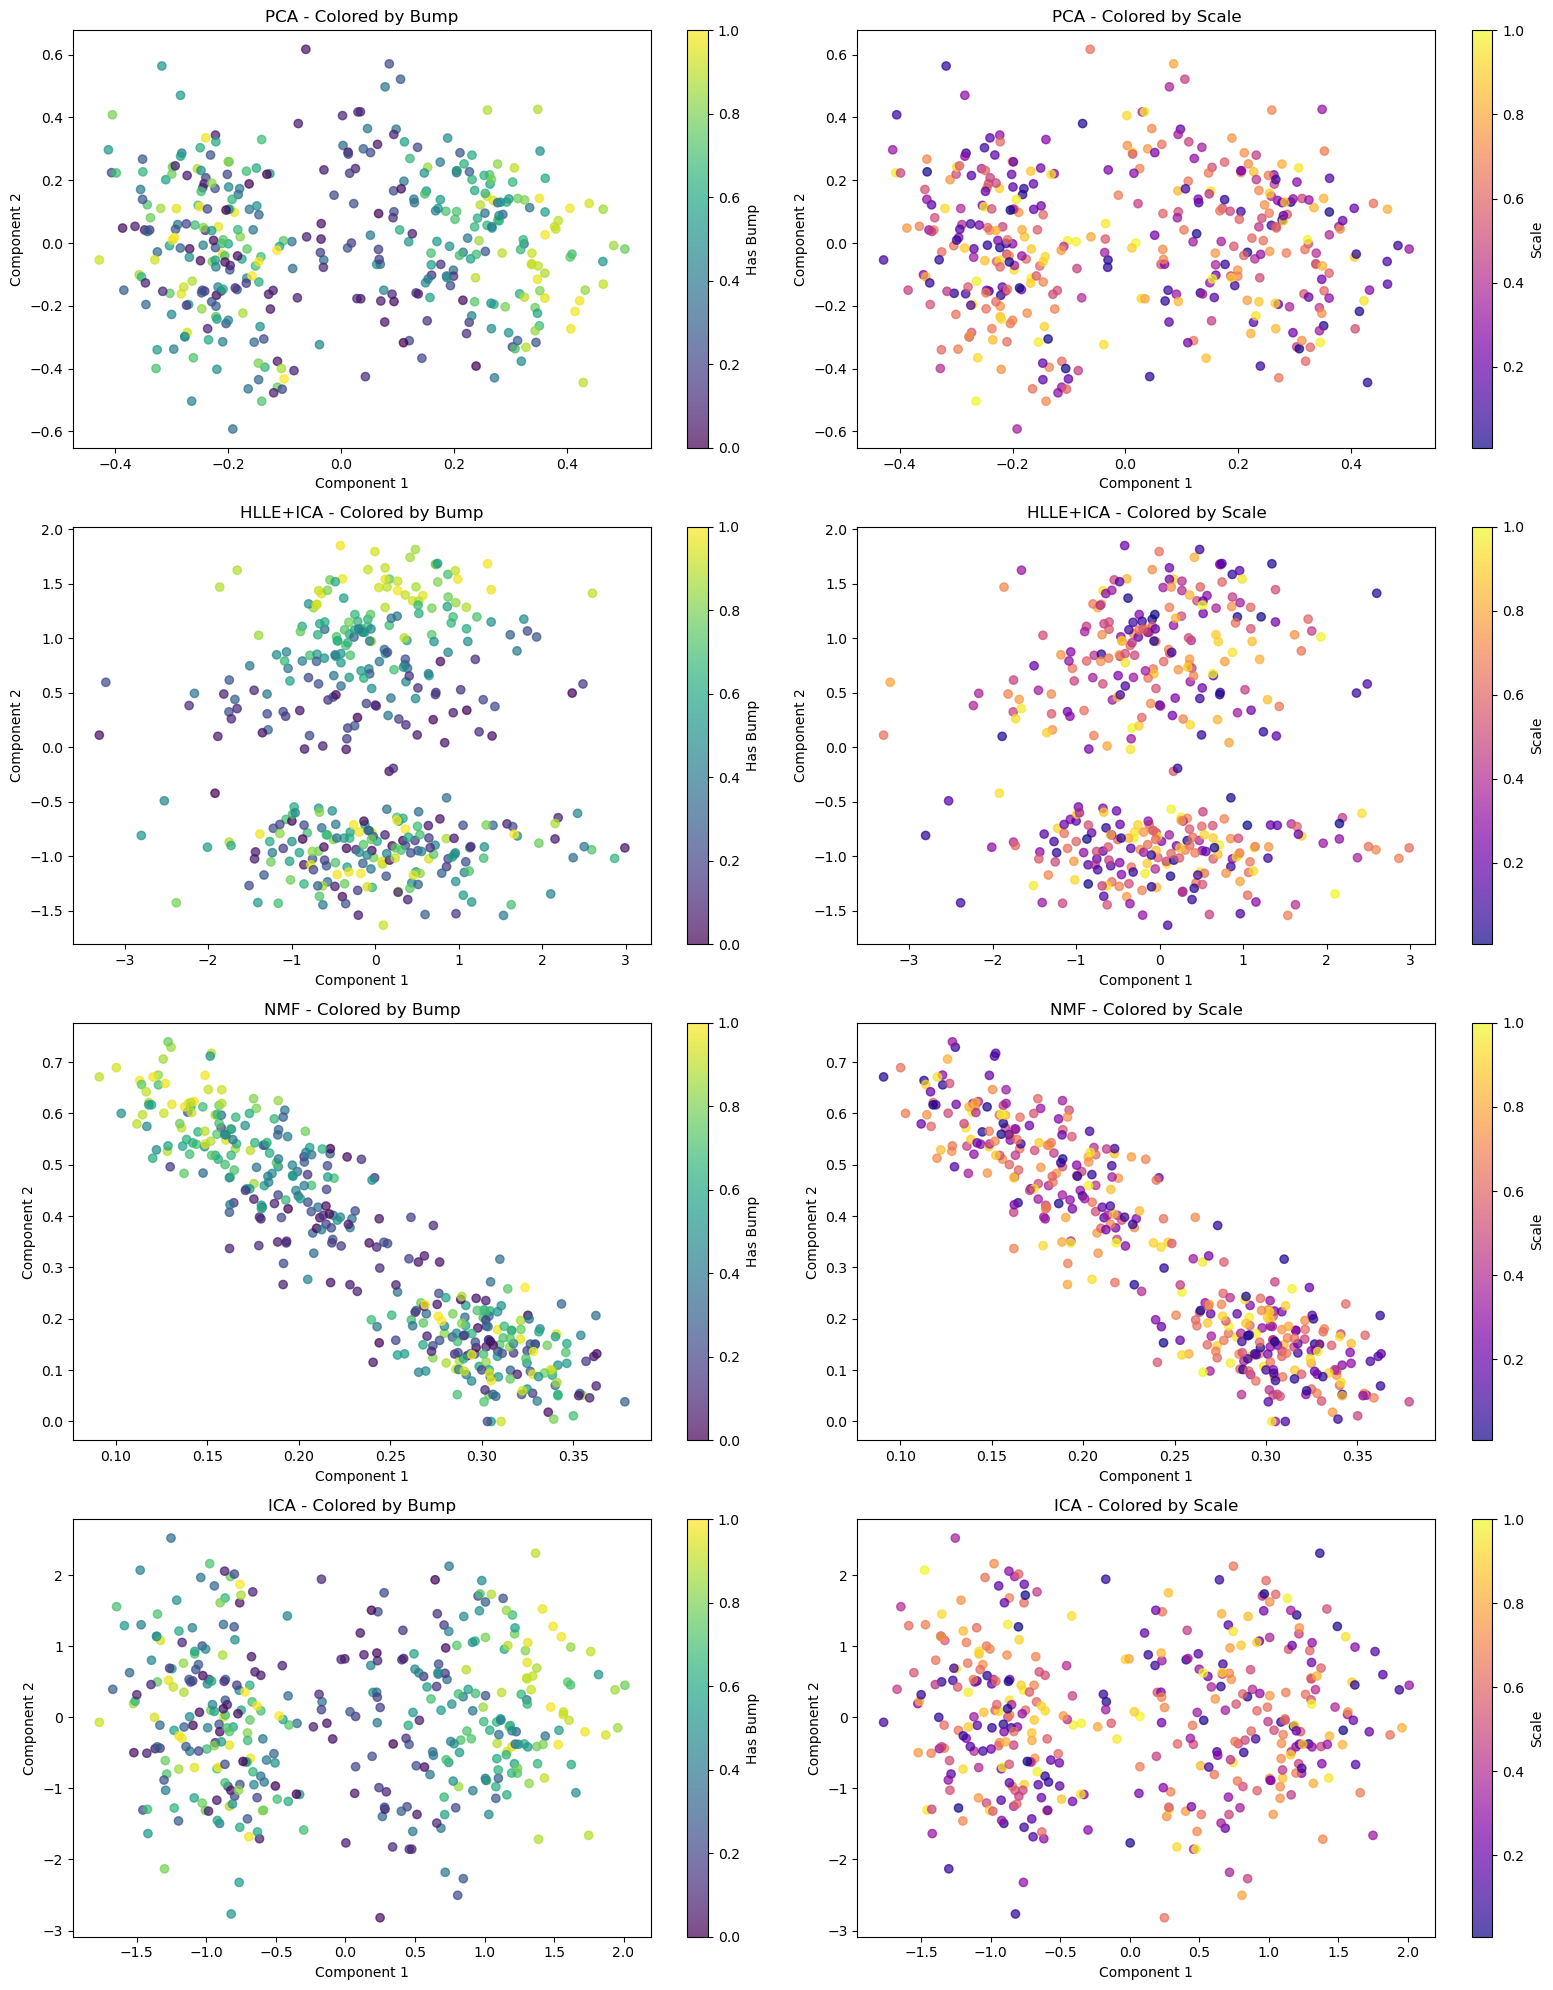

In [20]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Plot each technique with bump and scale coloring
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
for i, technique in enumerate(techniques):
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    # Plot colored by bump
    scatter = axes[i, 0].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=bump_sizes, cmap='viridis', alpha=0.7)
    axes[i, 0].set_title(f"{technique} - Colored by Bump")
    axes[i, 0].set_xlabel("Component 1")
    axes[i, 0].set_ylabel("Component 2")
    
    plt.colorbar(scatter, ax=axes[i, 0], label="Has Bump")

    
    # Plot colored by scale
    scatter = axes[i, 1].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=scales, cmap='plasma', alpha=0.7)
    axes[i, 1].set_title(f"{technique} - Colored by Scale")
    axes[i, 1].set_xlabel("Component 1")
    axes[i, 1].set_ylabel("Component 2")
    plt.colorbar(scatter, ax=axes[i, 1], label="Scale")

plt.tight_layout()
plt.savefig("latent_space_analysis.png", dpi=300)
plt.show()


In [21]:
# 5. Correlation Analysis
print("\nCorrelation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    bump_corr_1 = np.corrcoef(results[technique][:, 0], has_bump)[0, 1]
    bump_corr_2 = np.corrcoef(results[technique][:, 1], has_bump)[0, 1]
    scale_corr_1 = np.corrcoef(results[technique][:, 0], scales)[0, 1]
    scale_corr_2 = np.corrcoef(results[technique][:, 1], scales)[0, 1]
    
    print(f"\n{technique} Analysis:")
    print(f"Component 1 correlation with bump: {bump_corr_1:.4f}")
    print(f"Component 2 correlation with bump: {bump_corr_2:.4f}")
    print(f"Component 1 correlation with scale: {scale_corr_1:.4f}")
    print(f"Component 2 correlation with scale: {scale_corr_2:.4f}")




Correlation Analysis:

PCA Analysis:
Component 1 correlation with bump: 0.8973
Component 2 correlation with bump: 0.1444
Component 1 correlation with scale: -0.0074
Component 2 correlation with scale: -0.0395

HLLE+ICA Analysis:
Component 1 correlation with bump: -0.0553
Component 2 correlation with bump: 0.9249
Component 1 correlation with scale: 0.0249
Component 2 correlation with scale: -0.0111

NMF Analysis:
Component 1 correlation with bump: -0.8769
Component 2 correlation with bump: 0.8979
Component 1 correlation with scale: -0.0225
Component 2 correlation with scale: -0.0107

ICA Analysis:
Component 1 correlation with bump: 0.9087
Component 2 correlation with bump: 0.0173
Component 1 correlation with scale: -0.0143
Component 2 correlation with scale: 0.0376


In [12]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-1.352, Skew=0.152, Negent=0.056
component_1: Kurt=-0.301, Skew=-0.056, Negent=0.044
component_2: Kurt=-0.194, Skew=0.116, Negent=0.042
component_3: Kurt=-0.480, Skew=-0.044, Negent=0.042

HLLE+ICA Quality Metrics:
component_0: Kurt=0.600, Skew=0.078, Negent=0.372
component_1: Kurt=-1.504, Skew=0.136, Negent=0.507

NMF Quality Metrics:
component_0: Kurt=-1.284, Skew=-0.084, Negent=0.005
component_1: Kurt=-1.358, Skew=0.157, Negent=0.030

ICA Quality Metrics:
component_0: Kurt=-1.405, Skew=0.118, Negent=0.495
component_1: Kurt=-0.342, Skew=0.014, Negent=0.405


Projecting individual latent vectors onto learned components...
Projection shapes:
PCA: (369, 4)
ICA: (369, 2)
HLLE+ICA: (369, 2)


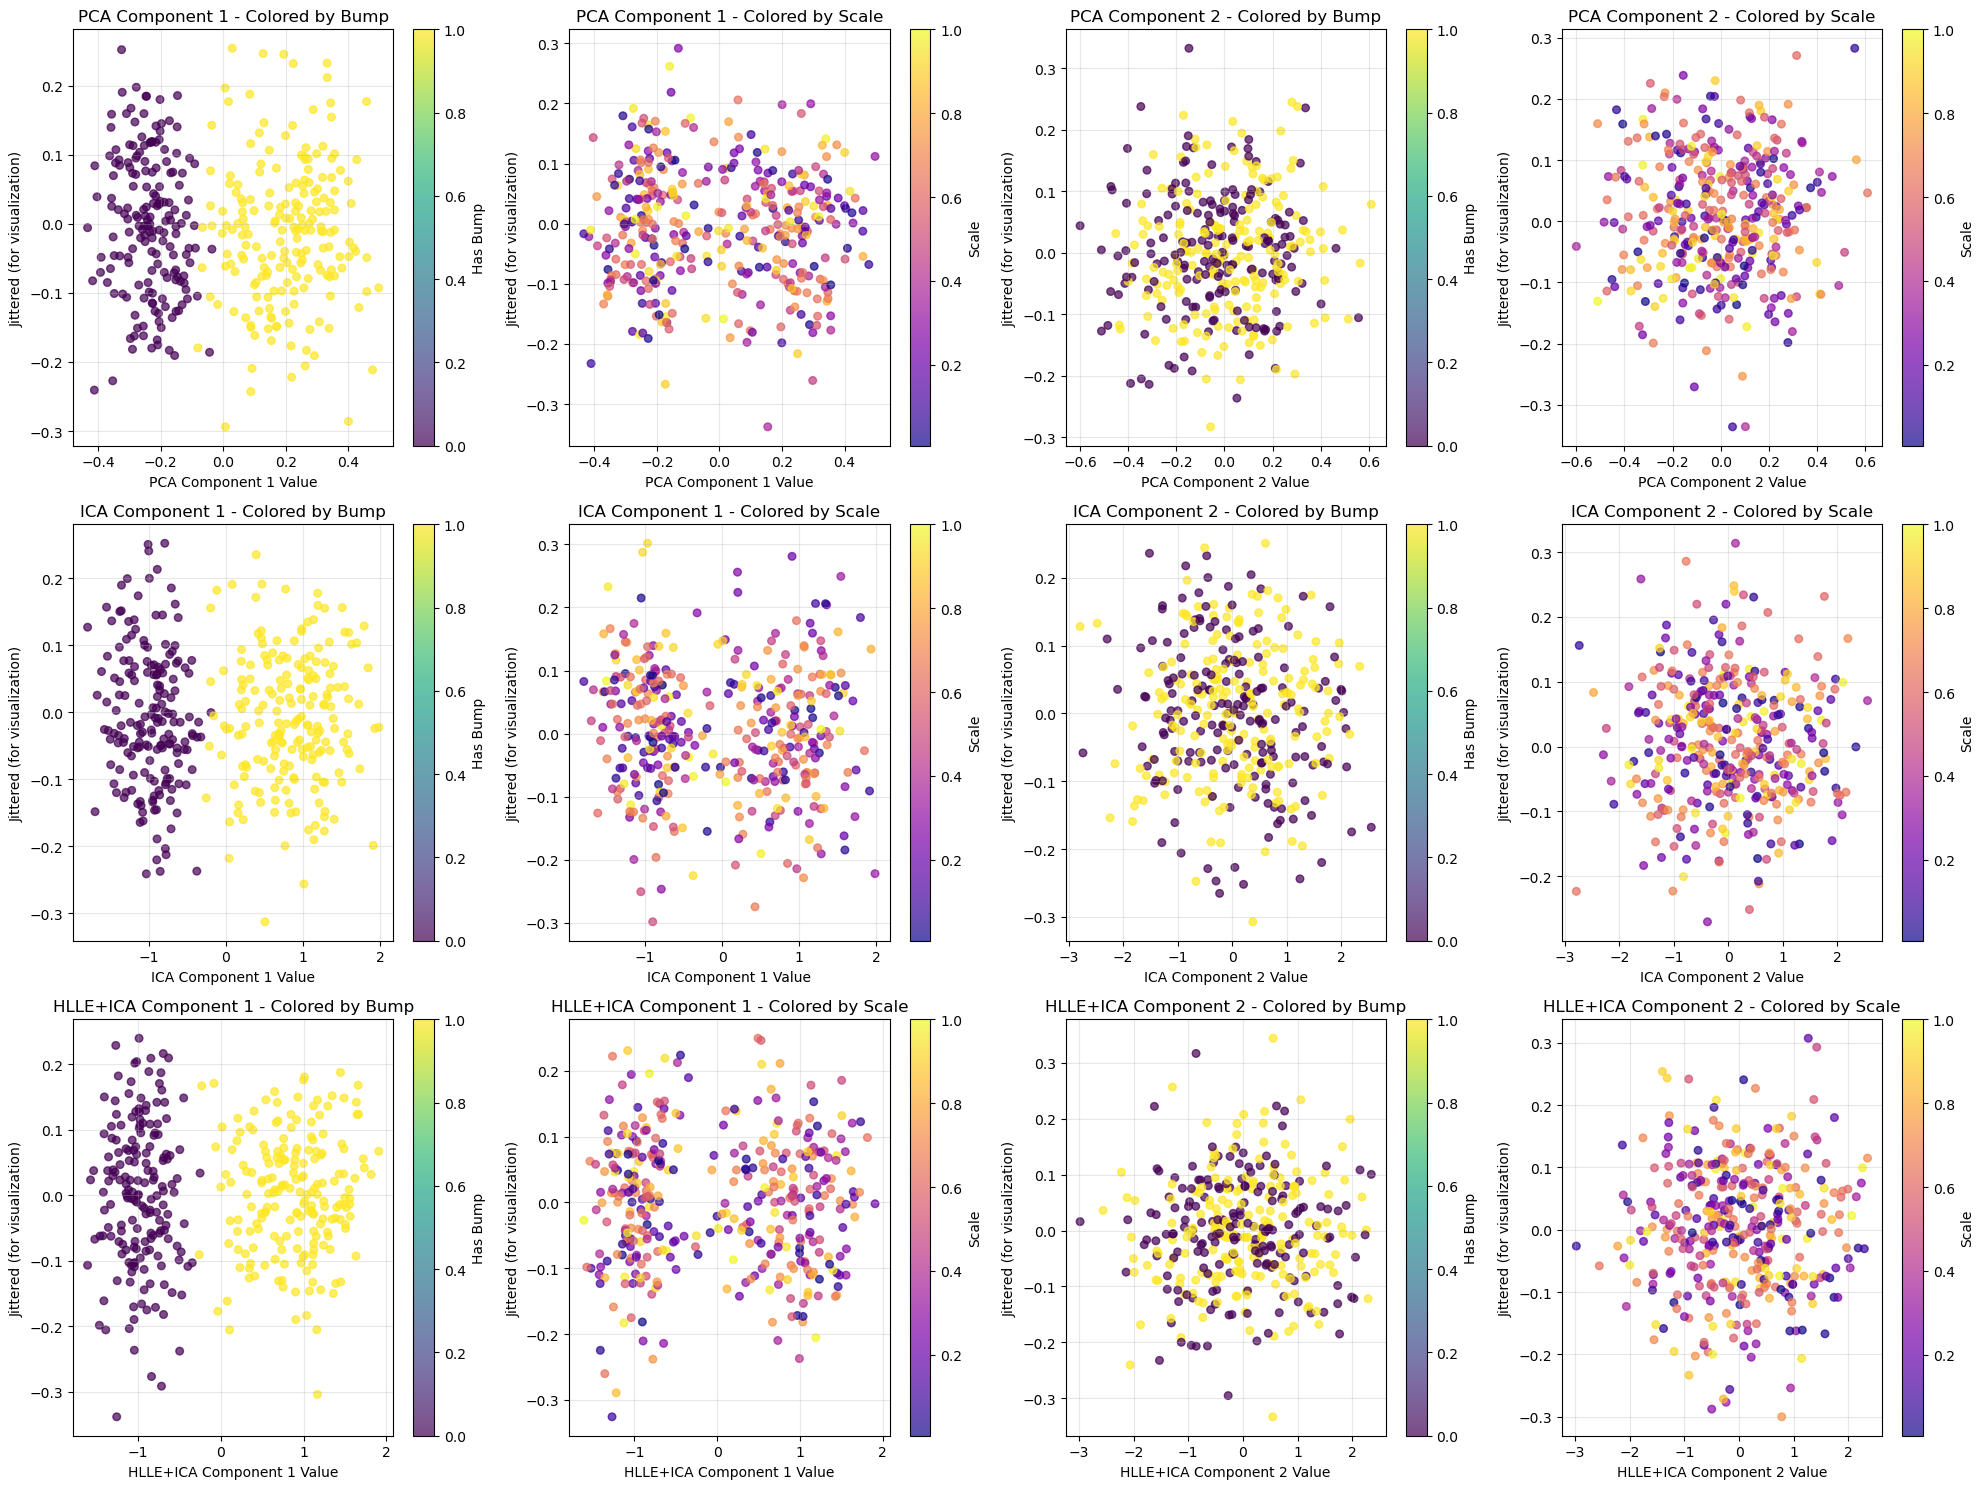

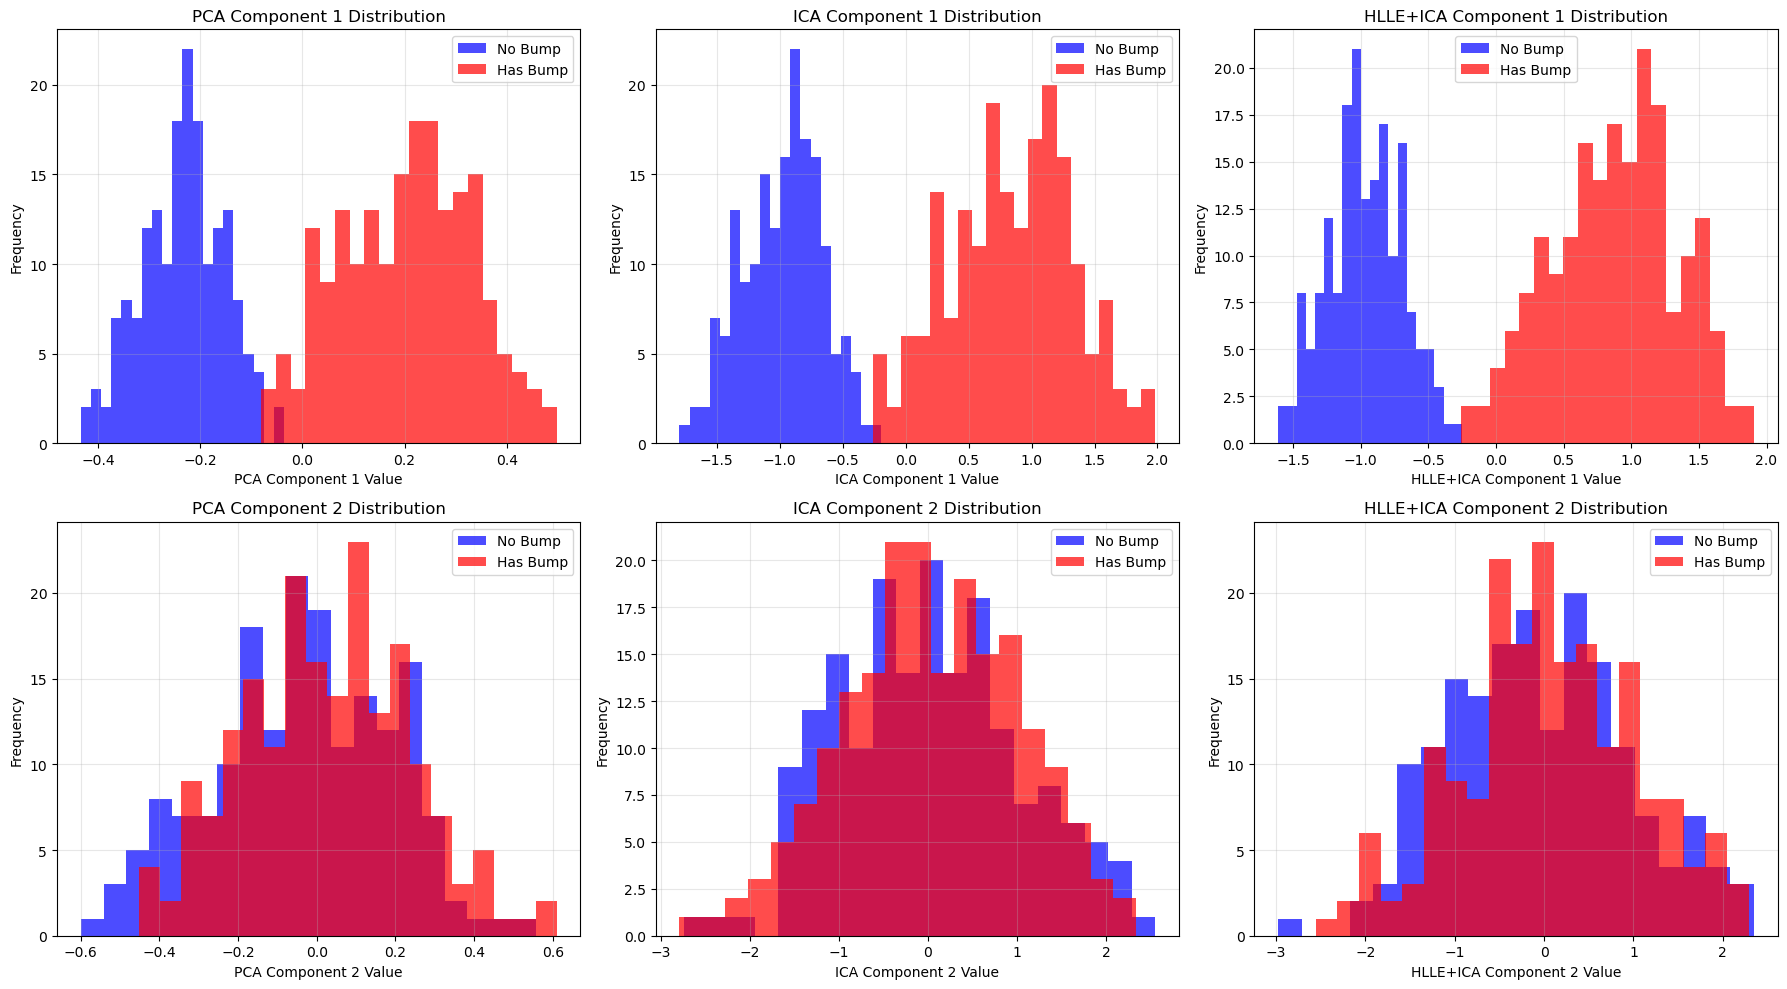

In [ ]:
# 9. Project individual latent vectors onto learned components
print("Projecting individual latent vectors onto learned components...")

# Use the already fitted transformers from your previous analysis
X_16d = latent_vectors.cpu().numpy()

# Dictionary to store projections
individual_projections = {}

# 9.1. Project onto PCA components (using the already fitted PCA)
# Get the PCA transformation matrix (components)
pca_components = pca.components_  # Shape: (n_components, n_features)
pca_projections = X_16d @ pca_components.T  # Shape: (n_samples, n_components)
individual_projections["PCA"] = pca_projections

# 9.2. Project onto ICA components (using the already fitted ICA)
# For ICA, we need to use the unmixing matrix
ica_components = ica.components_  # Shape: (n_components, n_features)  
ica_projections = X_16d @ ica_components.T  # Shape: (n_samples, n_components)
individual_projections["ICA"] = ica_projections

# 9.3. For HLLE+ICA, recreate the transformations with best parameters
if best_Y_hlle_ica is not None:
    # Get the best parameters
    best_n_neighbors = best_params[0]
    
    # Recreate HLLE transformation
    hlle_for_projection = LocallyLinearEmbedding(n_neighbors=best_n_neighbors,
                                                 n_components=2,
                                                 method='hessian',
                                                 eigen_solver='dense')
    hlle_for_projection.fit(X)
    
    # Apply HLLE to all 16D vectors
    hlle_transformed = hlle_for_projection.transform(X_16d)
    
    # Recreate ICA transformation that was applied to HLLE results
    ica_after_hlle = FastICA(n_components=2, random_state=42)
    # Fit on the original HLLE-transformed training data
    hlle_train_transformed = hlle_for_projection.transform(X)
    ica_after_hlle.fit(hlle_train_transformed)
    
    # Apply ICA to the HLLE-transformed data
    hlle_ica_projections = ica_after_hlle.transform(hlle_transformed)
    individual_projections["HLLE+ICA"] = hlle_ica_projections
else:
    individual_projections["HLLE+ICA"] = None

print("Projection shapes:")
for method, proj in individual_projections.items():
    if proj is not None:
        print(f"{method}: {proj.shape}")

# 10. Visualize projections of first two components against labels
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

methods = ["PCA", "ICA", "HLLE+ICA"]
for i, method in enumerate(methods):
    if individual_projections[method] is None:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        continue
    
    projections = individual_projections[method]
    
    # Component 1 - show scalar values with jitter, colored by bump
    jittered_y1 = np.random.normal(0, 0.1, len(projections))  # Random jitter for y-axis
    scatter1 = axes[i, 0].scatter(projections[:, 0], jittered_y1, c=has_bump, 
                                 cmap='viridis', alpha=0.7, s=30)
    axes[i, 0].set_xlabel(f"{method} Component 1 Value")
    axes[i, 0].set_ylabel("Jittered (for visualization)")
    axes[i, 0].set_title(f"{method} Component 1 - Colored by Bump")
    axes[i, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[i, 0], label="Has Bump")
    
    # Component 1 - show scalar values with jitter, colored by scale
    jittered_y2 = np.random.normal(0, 0.1, len(projections))  # Random jitter for y-axis
    scatter2 = axes[i, 1].scatter(projections[:, 0], jittered_y2, c=scales, 
                                 cmap='plasma', alpha=0.7, s=30)
    axes[i, 1].set_xlabel(f"{method} Component 1 Value")
    axes[i, 1].set_ylabel("Jittered (for visualization)")
    axes[i, 1].set_title(f"{method} Component 1 - Colored by Scale")
    axes[i, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[i, 1], label="Scale")
    
    # Component 2 - show scalar values with jitter, colored by bump
    if projections.shape[1] > 1:
        jittered_y3 = np.random.normal(0, 0.1, len(projections))
        scatter3 = axes[i, 2].scatter(projections[:, 1], jittered_y3, c=has_bump, 
                                     cmap='viridis', alpha=0.7, s=30)
        axes[i, 2].set_xlabel(f"{method} Component 2 Value")
        axes[i, 2].set_ylabel("Jittered (for visualization)")
        axes[i, 2].set_title(f"{method} Component 2 - Colored by Bump")
        axes[i, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[i, 2], label="Has Bump")
        
        # Component 2 - show scalar values with jitter, colored by scale
        jittered_y4 = np.random.normal(0, 0.1, len(projections))
        scatter4 = axes[i, 3].scatter(projections[:, 1], jittered_y4, c=scales, 
                                     cmap='plasma', alpha=0.7, s=30)
        axes[i, 3].set_xlabel(f"{method} Component 2 Value")
        axes[i, 3].set_ylabel("Jittered (for visualization)")
        axes[i, 3].set_title(f"{method} Component 2 - Colored by Scale")
        axes[i, 3].grid(True, alpha=0.3)
        plt.colorbar(scatter4, ax=axes[i, 3], label="Scale")
    else:
        axes[i, 2].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')
        axes[i, 3].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')

plt.tight_layout()
plt.savefig("component_projections_vs_labels_both_components.png", dpi=300, bbox_inches='tight')
plt.show()

# 13. Enhanced histogram visualization - both components (unchanged)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, method in enumerate(methods):
    if individual_projections[method] is None:
        axes[0, i].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        axes[1, i].text(0.5, 0.5, f"{method}\nFailed", ha='center', va='center')
        continue
    
    projections = individual_projections[method]
    bump_mask = has_bump == 1
    no_bump_mask = has_bump == 0
    
    # Component 1 histograms (top row)
    first_component = projections[:, 0]
    axes[0, i].hist(first_component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(first_component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"{method} Component 1 Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"{method} Component 1 Distribution")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Component 2 histograms (bottom row)
    if projections.shape[1] > 1:
        second_component = projections[:, 1]
        axes[1, i].hist(second_component[no_bump_mask], alpha=0.7, label='No Bump', 
                       bins=20, color='blue')
        axes[1, i].hist(second_component[bump_mask], alpha=0.7, label='Has Bump', 
                       bins=20, color='red')
        axes[1, i].set_xlabel(f"{method} Component 2 Value")
        axes[1, i].set_ylabel("Frequency")
        axes[1, i].set_title(f"{method} Component 2 Distribution")
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    else:
        axes[1, i].text(0.5, 0.5, f"Only 1\nComponent", ha='center', va='center')

plt.tight_layout()
plt.savefig("component_distributions_both_components.png", dpi=300, bbox_inches='tight')
plt.show()

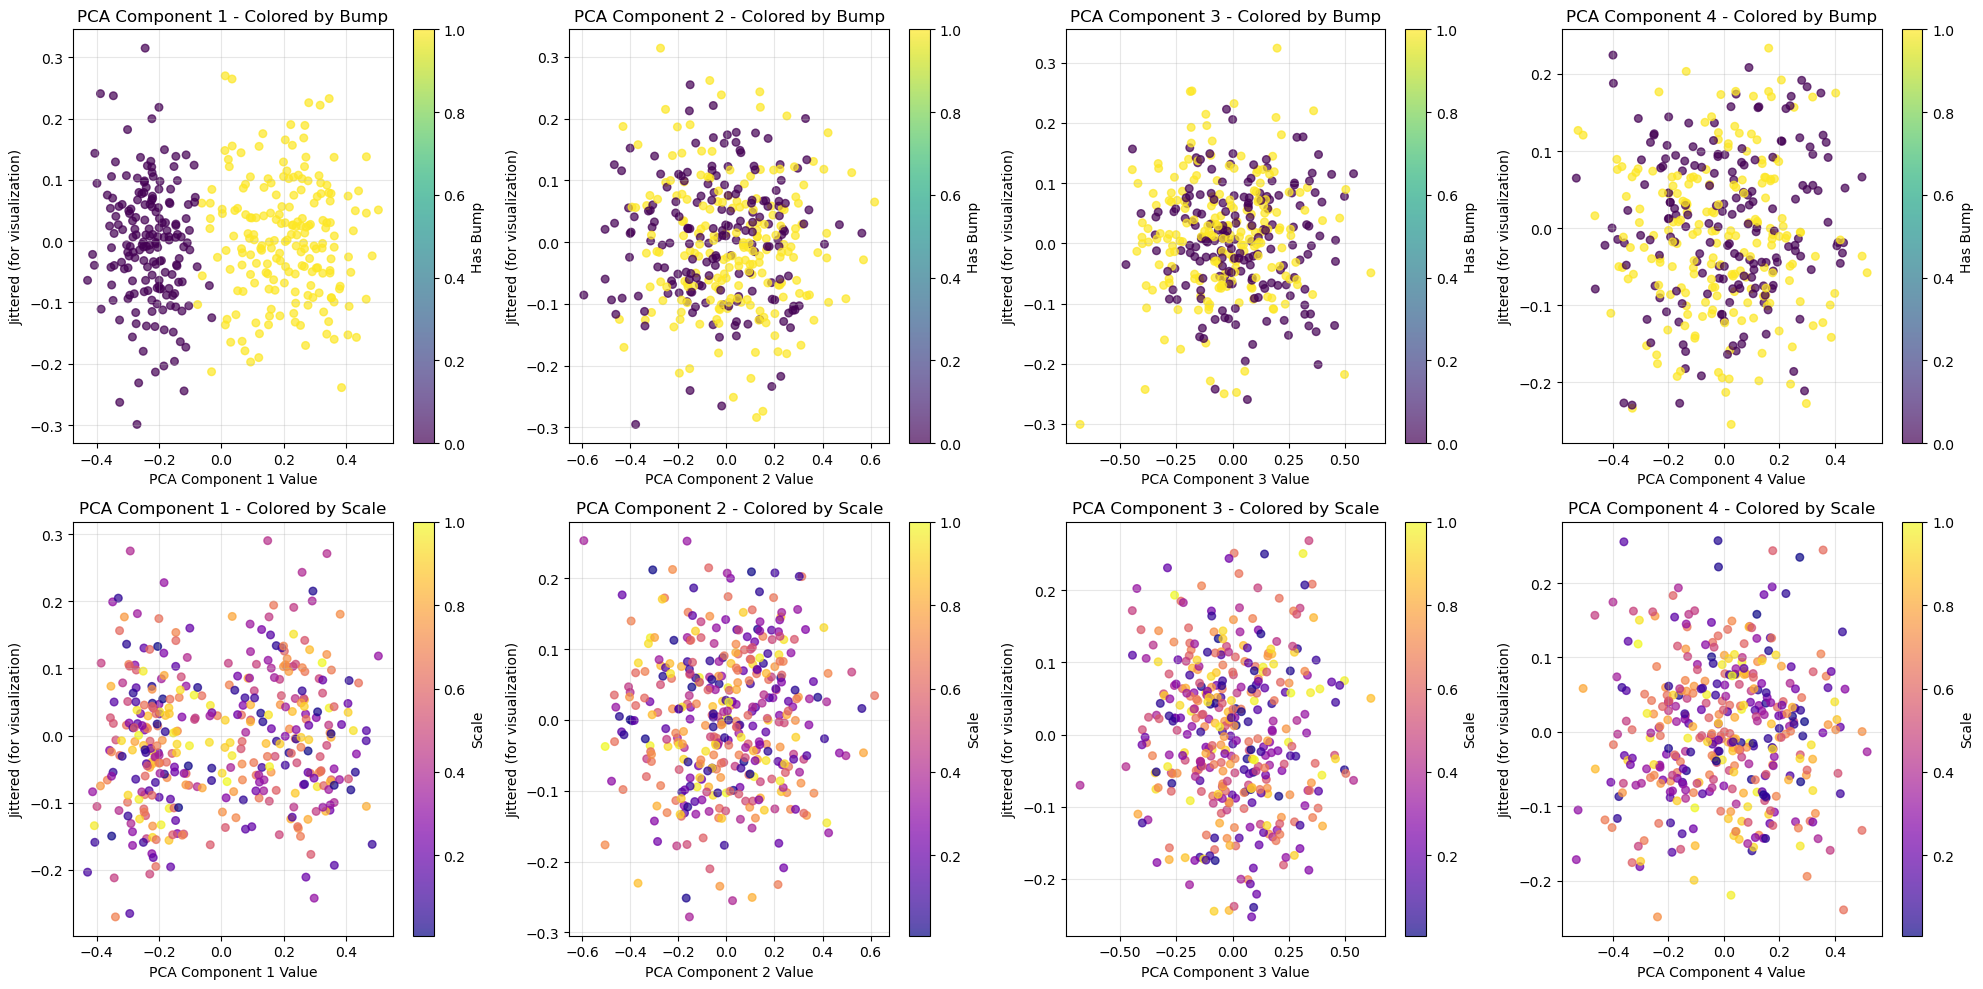

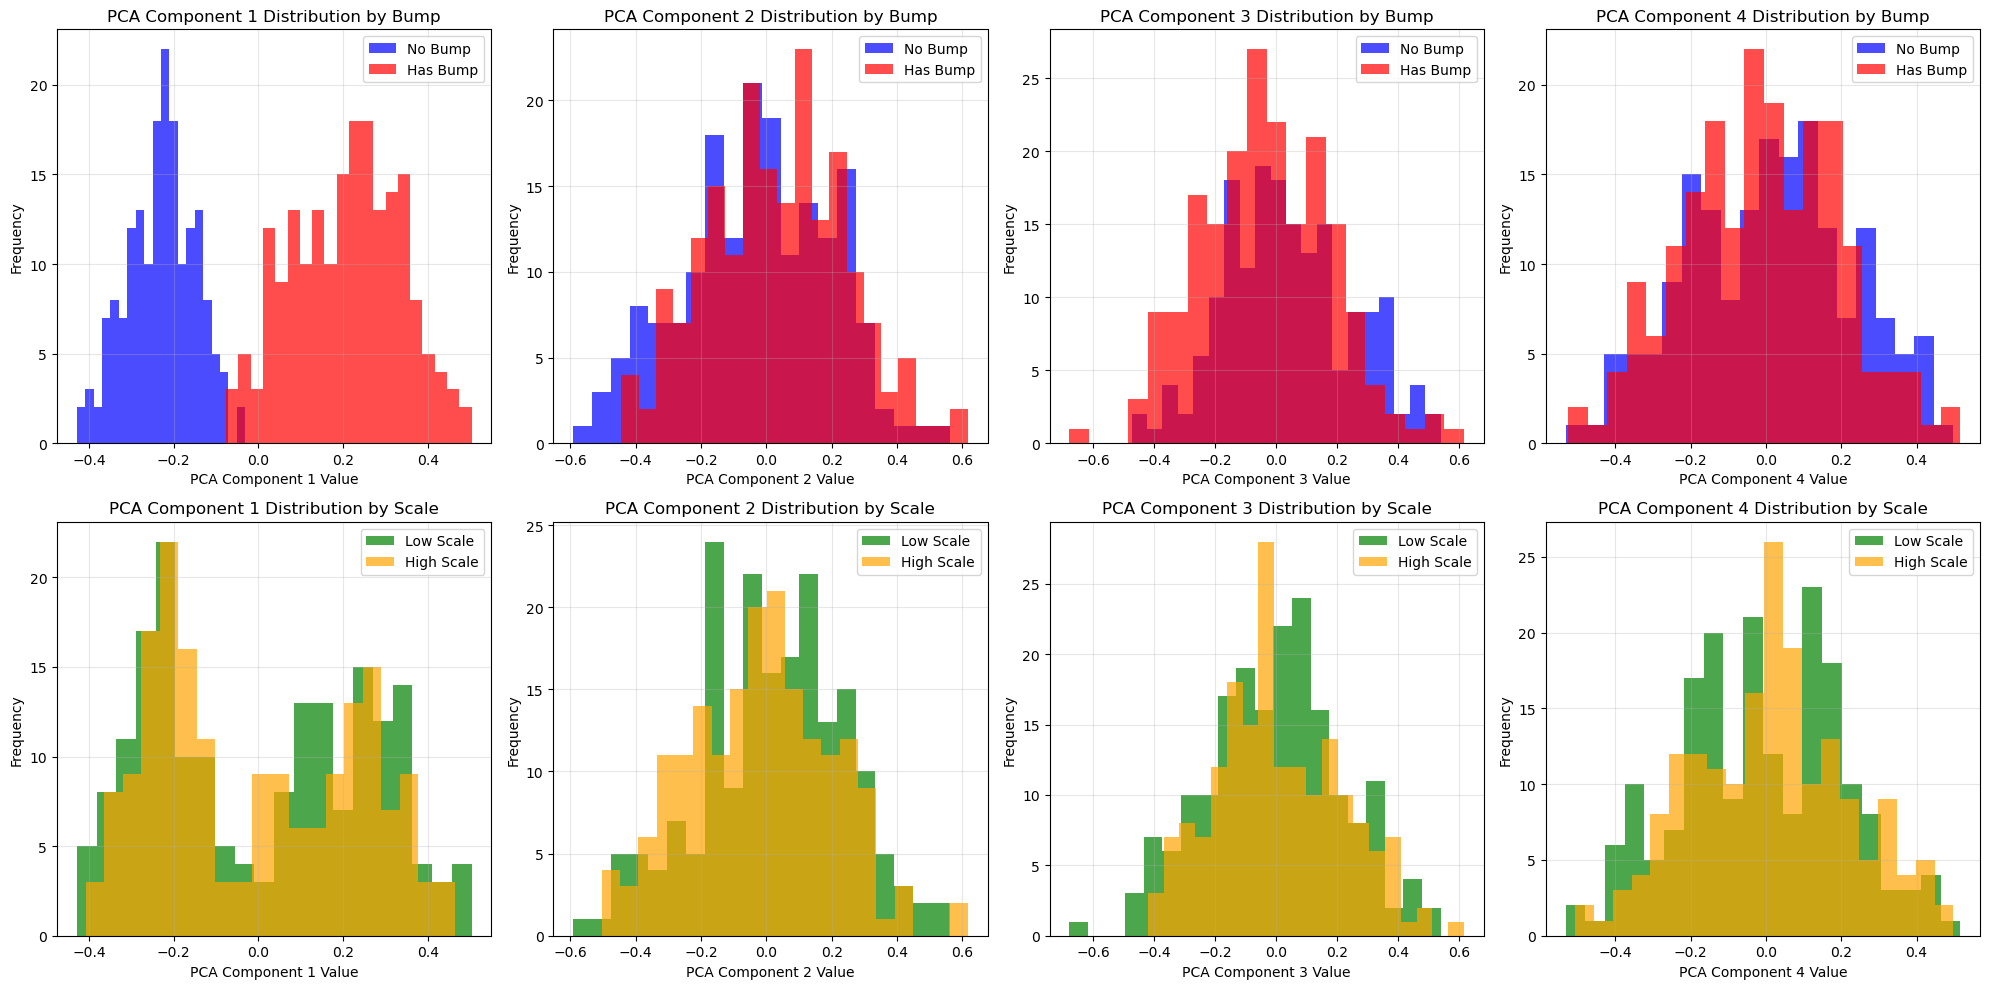


Detailed PCA Correlation Analysis:
PCA Component 1:
  Correlation with bump: 0.8973
  Correlation with scale: -0.0074
PCA Component 2:
  Correlation with bump: 0.1444
  Correlation with scale: -0.0395
PCA Component 3:
  Correlation with bump: -0.1751
  Correlation with scale: 0.0110
PCA Component 4:
  Correlation with bump: -0.0588
  Correlation with scale: -0.0105


In [ ]:
# Plot all 4 PCA components for bump and scale
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Get PCA results
pca_results = results["PCA"]

# Top row: All 4 components colored by bump
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=has_bump, 
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Jittered (for visualization)")
    axes[0, i].set_title(f"PCA Component {i+1} - Colored by Bump")
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label="Has Bump")

# Bottom row: All 4 components colored by scale
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[1, i].scatter(pca_results[:, i], jittered_y, c=scales, 
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Jittered (for visualization)")
    axes[1, i].set_title(f"PCA Component {i+1} - Colored by Scale")
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label="Scale")

plt.tight_layout()
plt.savefig("pca_all_components_vs_labels.png", dpi=300, bbox_inches='tight')
plt.show()

# Also create histogram distributions for all 4 PCA components
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

bump_mask = has_bump == 1
no_bump_mask = has_bump == 0

# Top row: Component distributions by bump
for i in range(4):
    component = pca_results[:, i]
    axes[0, i].hist(component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"PCA Component {i+1} Distribution by Bump")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Bottom row: Component distributions by scale (split into high/low scale)
scale_median = np.median(scales)
high_scale_mask = scales > scale_median
low_scale_mask = scales <= scale_median

for i in range(4):
    component = pca_results[:, i]
    axes[1, i].hist(component[low_scale_mask], alpha=0.7, label='Low Scale', 
                   bins=20, color='green')
    axes[1, i].hist(component[high_scale_mask], alpha=0.7, label='High Scale', 
                   bins=20, color='orange')
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].set_title(f"PCA Component {i+1} Distribution by Scale")
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_all_components_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Print correlation analysis for all 4 PCA components
print("\nDetailed PCA Correlation Analysis:")
for i in range(4):
    bump_corr = np.corrcoef(pca_results[:, i], has_bump)[0, 1]
    scale_corr = np.corrcoef(pca_results[:, i], scales)[0, 1]
    print(f"PCA Component {i+1}:")
    print(f"  Correlation with bump: {bump_corr:.4f}")
    print(f"  Correlation with scale: {scale_corr:.4f}")


Analyzing scale encoding across all 16 dimensions:
Latent dim 1: scale correlation = -0.1027
Latent dim 2: scale correlation = 0.0045
Latent dim 3: scale correlation = -0.1122
Latent dim 4: scale correlation = 0.0299
Latent dim 5: scale correlation = -0.0935
Latent dim 6: scale correlation = 0.0301
Latent dim 7: scale correlation = -0.0065
Latent dim 8: scale correlation = -0.0578
Latent dim 9: scale correlation = 0.0111
Latent dim 10: scale correlation = 0.0555
Latent dim 11: scale correlation = -0.0134
Latent dim 12: scale correlation = 0.0592
Latent dim 13: scale correlation = 0.0398
Latent dim 14: scale correlation = -0.0427
Latent dim 15: scale correlation = -0.0789
Latent dim 16: scale correlation = -0.0595

Linear regression R² for predicting scale from all 16 dimensions: 0.0600
This suggests scale information is poorly encoded in the full latent space


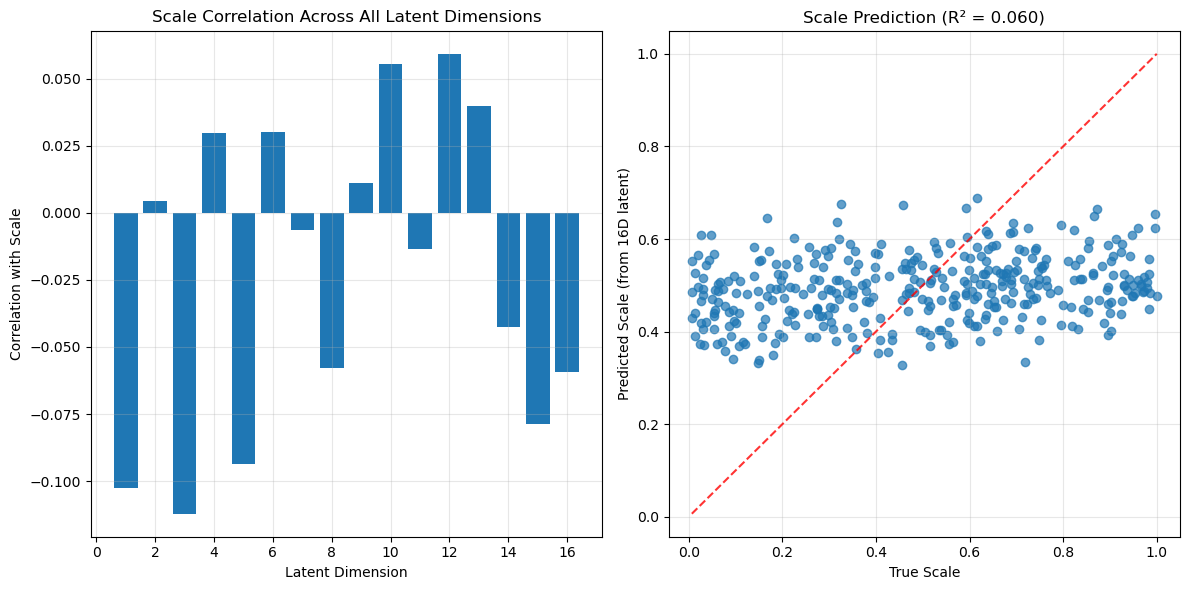

In [21]:
# Test if scale information is distributed across all dimensions
print("\nAnalyzing scale encoding across all 16 dimensions:")

# Calculate correlation of each individual latent dimension with scale
latent_scale_correlations = []
for dim in range(X.shape[1]):
    corr = np.corrcoef(X[:, dim], scales)[0, 1]
    latent_scale_correlations.append(corr)
    print(f"Latent dim {dim+1}: scale correlation = {corr:.4f}")

# Check if scale can be predicted using all 16 dimensions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train a linear model to predict scale from all 16 latent dimensions
lr = LinearRegression()
lr.fit(X, scales)
predicted_scales = lr.predict(X)
r2 = r2_score(scales, predicted_scales)

print(f"\nLinear regression R² for predicting scale from all 16 dimensions: {r2:.4f}")
print(f"This suggests scale information is {'well' if r2 > 0.7 else 'poorly'} encoded in the full latent space")

# Visualize the correlation pattern
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 17), latent_scale_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Scale')
plt.title('Scale Correlation Across All Latent Dimensions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(scales, predicted_scales, alpha=0.7)
plt.xlabel('True Scale')
plt.ylabel('Predicted Scale (from 16D latent)')
plt.title(f'Scale Prediction (R² = {r2:.3f})')
plt.plot([scales.min(), scales.max()], [scales.min(), scales.max()], 'r--', alpha=0.8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scale_analysis_full_latent_space.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.080, Calinski-Harabasz=32.0, Davies-Bouldin=3.342
K=3: Silhouette=0.076, Calinski-Harabasz=23.6, Davies-Bouldin=3.337
K=4: Silhouette=0.058, Calinski-Harabasz=20.7, Davies-Bouldin=3.507
K=5: Silhouette=0.060, Calinski-Harabasz=18.9, Davies-Bouldin=3.157
K=6: Silhouette=0.053, Calinski-Harabasz=17.4, Davies-Bouldin=3.022
K=7: Silhouette=0.051, Calinski-Harabasz=15.8, Davies-Bouldin=2.831
K=8: Silhouette=0.059, Calinski-Harabasz=15.0, Davies-Bouldin=2.768
K=9: Silhouette=0.050, Calinski-Harabasz=14.0, Davies-Bouldin=2.779
K=10: Silhouette=0.055, Calinski-Harabasz=13.6, Davies-Bouldin=2.673

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 10


In [15]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.081, AIC=16657.8, BIC=17850.6
K=3: Silhouette=0.076, AIC=16792.8, BIC=18583.9
K=4: Silhouette=0.048, AIC=16843.3, BIC=19232.8
K=5: Silhouette=0.036, AIC=16942.3, BIC=19930.2
K=6: Silhouette=0.045, AIC=17059.2, BIC=20645.4
K=7: Silhouette=0.041, AIC=17155.7, BIC=21340.3
K=8: Silhouette=0.042, AIC=17244.0, BIC=22026.9
K=9: Silhouette=0.047, AIC=17436.4, BIC=22817.6
K=10: Silhouette=0.045, AIC=17567.1, BIC=23546.7

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 369 noise points (invalid)
eps=0.5: 0 clusters, 369 noise points (invalid)
eps=0.7: 0 clusters, 369 noise points (invalid)
eps=1.0: 0 clusters, 369 noise points (invalid)
eps=1.5: 0 clusters, 369 noise points (invalid)
eps=2.0: 0 clusters, 369 noise points (invalid)


In [16]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=3: Silhouette=0.023
Linkage=ward, K=4: Silhouette=0.026
Linkage=ward, K=5: Silhouette=0.022
Linkage=complete, K=3: Silhouette=0.017
Linkage=complete, K=4: Silhouette=0.017
Linkage=complete, K=5: Silhouette=0.019
Linkage=average, K=3: Silhouette=0.054
Linkage=average, K=4: Silhouette=0.032
Linkage=average, K=5: Silhouette=0.019

5. Spectral Clustering:
K=3: Silhouette=0.048
K=4: Silhouette=0.013
K=5: Silhouette=-0.003



6. Visualization of Clustering Results:


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Using UMAP for visualization


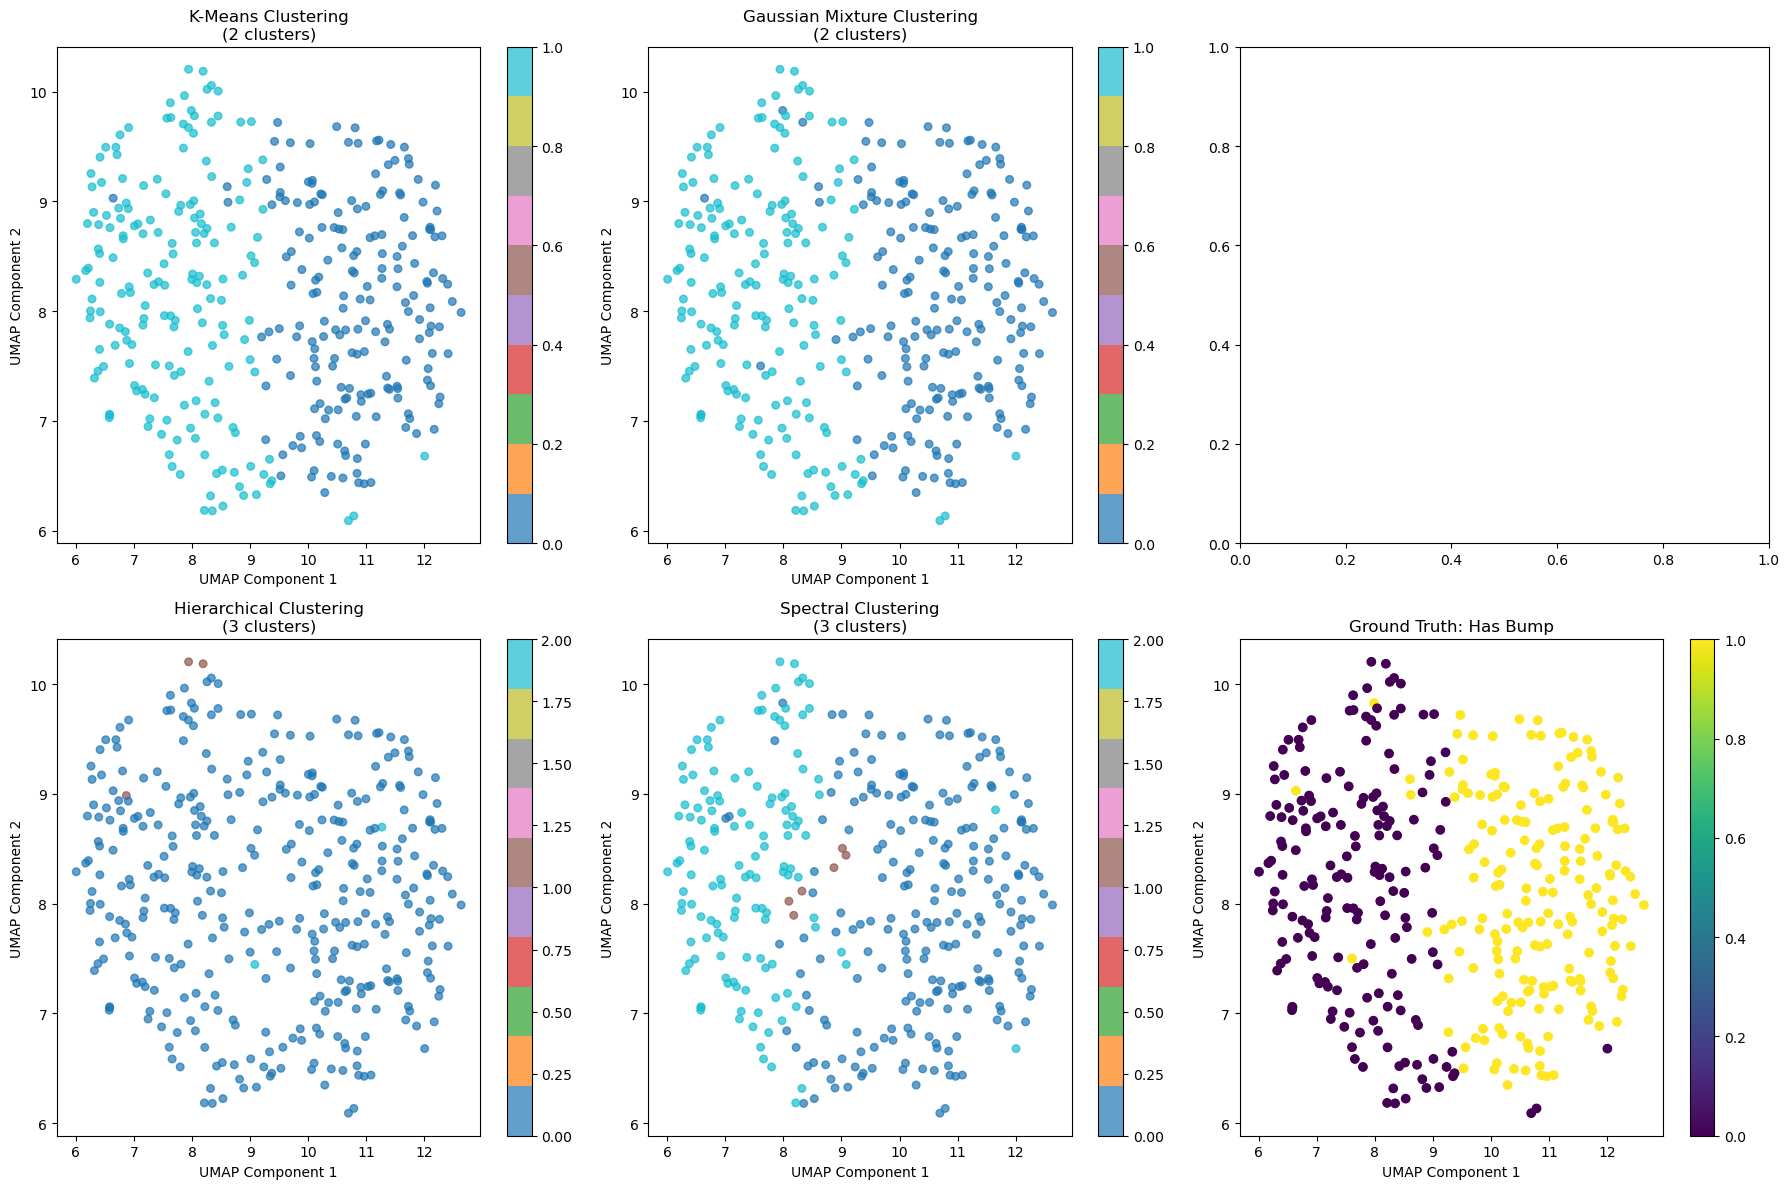

In [18]:
# 6. Visualize clustering results using dimensionality reduction
print("\n6. Visualization of Clustering Results:")

# Use UMAP for better visualization of clusters
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print("Using UMAP for visualization")
except ImportError:
    # Fallback to t-SNE if UMAP is not available
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)
    print("Using t-SNE for visualization")

# Plot clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

for i, (method, name) in enumerate(zip(methods, method_names)):
    if method in clustering_results:
        labels = clustering_results[method]
        scatter = axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, 
                                 cmap='tab10', alpha=0.7, s=30)
        axes[i].set_title(f'{name} Clustering\n({len(set(labels))} clusters)')
        axes[i].set_xlabel('UMAP Component 1')
        axes[i].set_ylabel('UMAP Component 2')
        plt.colorbar(scatter, ax=axes[i])

# Compare with your known labels
axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis', alpha=0.7, s=30)
axes[5].set_title('Ground Truth: Has Bump')
axes[5].set_xlabel('UMAP Component 1')
axes[5].set_ylabel('UMAP Component 2')
plt.colorbar(axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis'), ax=axes[5])

plt.tight_layout()
plt.savefig("clustering_results_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 7. Analyze cluster characteristics
print("\n7. Cluster Analysis:")

# Analyze the best K-means clustering
best_labels = clustering_results['KMeans_Best']
unique_clusters = sorted(set(best_labels))

print(f"\nAnalyzing K-Means clustering with {len(unique_clusters)} clusters:")

cluster_analysis = {}
for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id
    
    # Analyze cluster characteristics
    cluster_bump_ratio = np.mean(has_bump[cluster_mask])
    cluster_scale_mean = np.mean(scales[cluster_mask])
    cluster_scale_std = np.std(scales[cluster_mask])
    cluster_size = np.sum(cluster_mask)
    
    cluster_analysis[cluster_id] = {
        'size': cluster_size,
        'bump_ratio': cluster_bump_ratio,
        'scale_mean': cluster_scale_mean,
        'scale_std': cluster_scale_std
    }
    
    print(f"Cluster {cluster_id}:")
    print(f"  Size: {cluster_size} samples")
    print(f"  Bump ratio: {cluster_bump_ratio:.3f}")
    print(f"  Scale mean±std: {cluster_scale_mean:.3f}±{cluster_scale_std:.3f}")

# 8. Create new labels from clustering
print("\n8. Creating Training Labels from Clusters:")

# You can use these cluster labels as new training targets
cluster_labels_for_training = best_labels

# Save the cluster assignments
np.save("unsupervised_cluster_labels.npy", cluster_labels_for_training)
print(f"Saved cluster labels to 'unsupervised_cluster_labels.npy'")
print(f"Shape: {cluster_labels_for_training.shape}")
print(f"Unique clusters: {sorted(set(cluster_labels_for_training))}")

# You can now use cluster_labels_for_training as your new training targets
# for any supervised learning task


7. Cluster Analysis:

Analyzing K-Means clustering with 2 clusters:
Cluster 0:
  Size: 190 samples
  Bump ratio: 1.000
  Scale mean±std: 0.493±0.280
Cluster 1:
  Size: 179 samples
  Bump ratio: 0.017
  Scale mean±std: 0.492±0.297

8. Creating Training Labels from Clusters:
Saved cluster labels to 'unsupervised_cluster_labels.npy'
Shape: (369,)
Unique clusters: [0, 1]
